# Part C: SOTA Model — Chronos (Zero-Shot Time Series Forecasting)

This notebook implements Amazon's Chronos.

Data source: group2_m5_full_feature_dataset_v1.parquet (all categories,
all stores, 2014–2016 time window)

## Initial Exploration (30-series sample) - FINDINGS NOT USED FOR PRESENTATION IN CLASS.

To validate the setup before running on the full dataset, we first
tested Chronos on a random sample of 30 item-store series. This was
mainly to make sure the pipeline worked and the metrics were calculating
correctly before committing to a 2+ hour full run. These results are
not included in the final model comparison.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
 !pip install chronos-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 116.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
# imports
import torch
import numpy as np
import pandas as pd
from chronos import ChronosPipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error



---




## 30 Series Sample Model Setup

In [ ]:
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cpu",  # changed from cpu
    torch_dtype=torch.float32,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

## 30 Sample Series Data Preparation
Load parquet dataset and extract only the columns needed
for Chronos (item_id, store_id, date, sales). We sample 30 item-store
combinations for evaluation using an 80/20 time-based train/test split
with a 28-day forecast horizon.

In [ ]:
df_chronos = pd.read_parquet(
    "/content/drive/MyDrive/Advance Machine Learning Project - Team 2/group2_m5_full_feature_dataset_v1.parquet",
    columns=["item_id", "store_id", "date", "sales"]
)
df_chronos["date"] = pd.to_datetime(df_chronos["date"])
df_chronos = df_chronos.sort_values(["item_id", "store_id", "date"])

split_date = df_chronos["date"].quantile(0.8)
HORIZON = 28

series_keys = (
    df_chronos[["item_id", "store_id"]]
    .drop_duplicates()
    .sample(30, random_state=42)
)

In [ ]:
df_full = pd.read_parquet(
    "/content/drive/MyDrive/Advance Machine Learning Project - Team 2/group2_m5_full_feature_dataset_v1.parquet"
)
print(df_full["date"].min(), "to", df_full["date"].max())
print(df_full.shape)
print(df_full.columns.tolist())


2014-07-17 00:00:00 to 2016-04-24 00:00:00
(19368893, 50)
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'weekday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'day_of_month', 'week_of_year', 'quarter', 'is_month_start', 'is_month_end', 'is_weekend', 'season', 'snap_flag', 'event_flag', 'event_cultural', 'event_national', 'event_religious', 'event_sporting', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'price_lag_7', 'price_change_pct', 'cat_avg_price', 'relative_price_cat', 'dept_avg_price', 'relative_price_dept', 'price_rank_dept', 'log_sales', 'log_price', 'event_lag_1', 'event_lead_1', 'log_price_diff_7']


## 30 Sample Series Running Forecasts
For each sampled series, we pass historical sales as context to Chronos
and generate 20 probabilistic forecast trajectories. The median trajectory
is used as the point forecast.

In [ ]:
# forecasts
all_preds, all_actuals = [], []

for _, row in series_keys.iterrows():
    mask = (
        (df_chronos["item_id"] == row["item_id"]) &
        (df_chronos["store_id"] == row["store_id"])
    )
    series = df_chronos[mask].set_index("date")["sales"]
    train_series = series[series.index <= split_date]
    test_series  = series[series.index >  split_date].iloc[:HORIZON]

    if len(train_series) < 30 or len(test_series) == 0:
        continue

    context = torch.tensor(train_series.values, dtype=torch.float32)
    forecast = pipeline.predict(
        context.unsqueeze(0),
        prediction_length=len(test_series),
        num_samples=20,
    )
    median_forecast = forecast[0].median(dim=0).values.numpy()
    all_preds.extend(median_forecast)
    all_actuals.extend(test_series.values)

## 30 Sample Series Results

In [ ]:
# Evaluate
all_preds   = np.array(all_preds)
all_actuals = np.array(all_actuals)

rmse_chronos = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae_chronos  = mean_absolute_error(all_actuals, all_preds)

print("=== Chronos (Zero-Shot) ===")
print(f"RMSE: {rmse_chronos:.2f}")
print(f"MAE : {mae_chronos:.2f}")

=== Chronos (Zero-Shot) ===
RMSE: 1.87
MAE : 0.68


In [ ]:
from sklearn.metrics import r2_score
r2_chronos = r2_score(all_actuals, all_preds)
print(f"R2: {r2_chronos:.4f}")

R2: 0.0623


In [ ]:
import pandas as pd, os

row = pd.DataFrame([{
    "model": "Chronos",
    "RMSE": rmse_chronos,
    "MAE": mae_chronos,
    "R2": r2_chronos
}])

file_path = "/content/drive/MyDrive/Advance Machine Learning Project - Team 2/chronos_results.csv"
row.to_csv(file_path, index=False)
print("saved Chronos results!")

saved Chronos results!


## 30 Sample Series Forecast Visualization


In [ ]:
# Find series with consistent sales (low variance, decent mean)
series_stats = df_chronos.groupby(["item_id", "store_id"])["sales"].agg(["mean", "std"])
series_stats["cv"] = series_stats["std"] / series_stats["mean"]  # coefficient of variation
# want high mean, low cv (consistent)
good_series = series_stats[
    (series_stats["mean"] > 2) &
    (series_stats["cv"] < 1)
].nlargest(10, "mean").index

for item_id, store_id in good_series:
    sample_mask = (
        (df_chronos["item_id"] == item_id) &
        (df_chronos["store_id"] == store_id)
    )
    sample_series = df_chronos[sample_mask].set_index("date")["sales"]
    train_s = sample_series[sample_series.index <= split_date]
    test_s = sample_series[sample_series.index > split_date].iloc[:HORIZON]
    if len(test_s) > 0:
        break

/tmp/ipykernel_5429/2931597414.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  series_stats = df_chronos.groupby(["item_id", "store_id"])["sales"].agg(["mean", "std"])


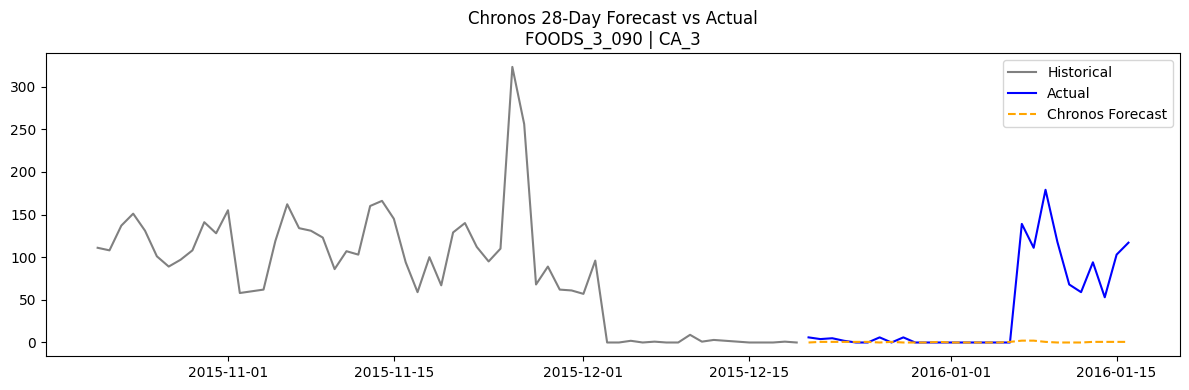

In [ ]:
import matplotlib.pyplot as plt
context = torch.tensor(train_s.values, dtype=torch.float32)
forecast = pipeline.predict(context.unsqueeze(0), prediction_length=HORIZON, num_samples=20)
median_f = forecast[0].median(dim=0).values.numpy()

plt.figure(figsize=(12, 4))
plt.plot(train_s.index[-60:], train_s.values[-60:], label="Historical", color="gray")
plt.plot(test_s.index, test_s.values, label="Actual", color="blue")
plt.plot(test_s.index, median_f, label="Chronos Forecast", color="orange", linestyle="--")
plt.title(f"Chronos 28-Day Forecast vs Actual\n{item_id} | {store_id}")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_5429/1036628169.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_keys = cat_series.groupby(["item_id", "store_id"])["sales"].mean()


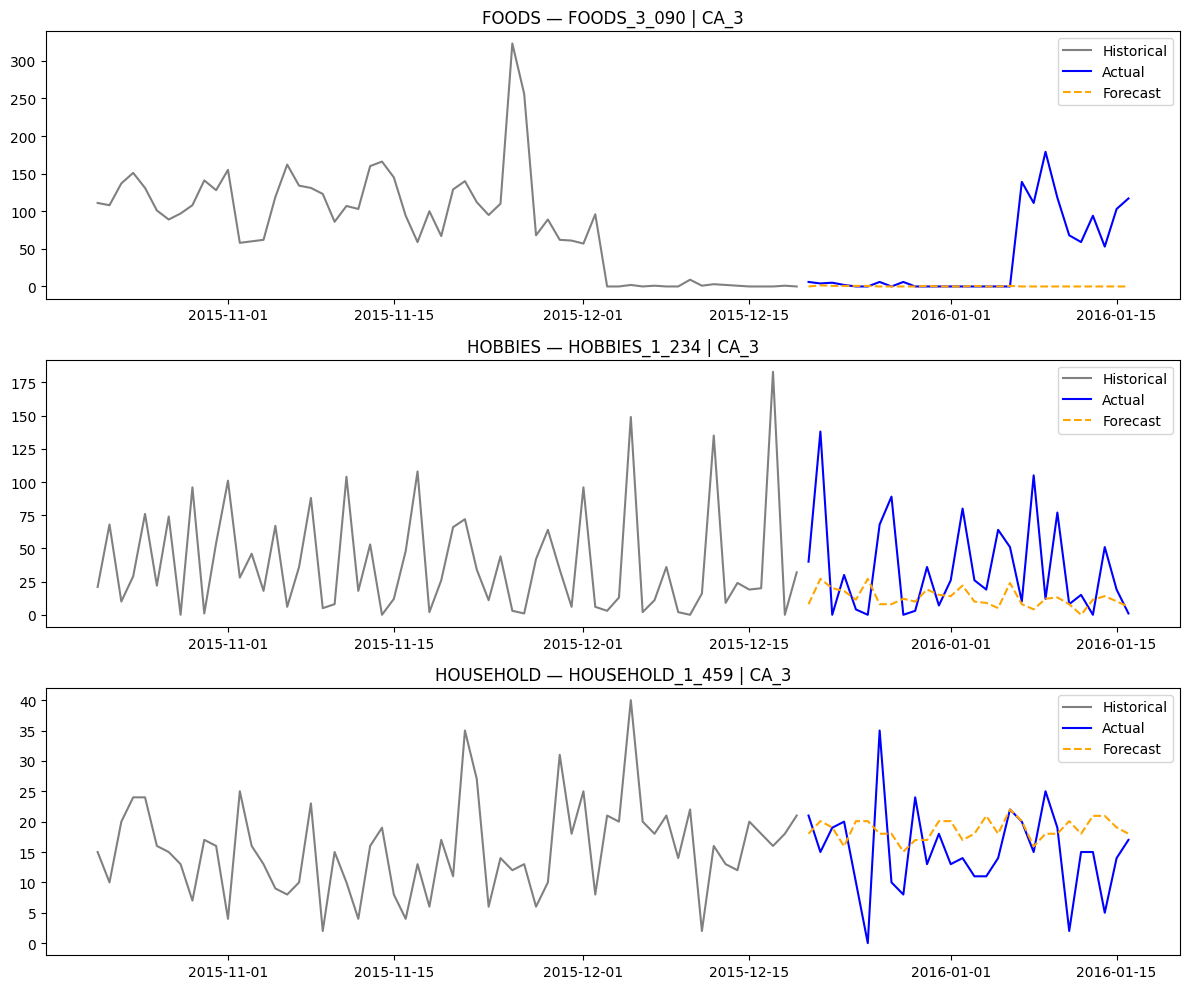

In [ ]:
# Plot one series per category
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
categories = ["FOODS", "HOBBIES", "HOUSEHOLD"]

for idx, cat in enumerate(categories):
    # Find a good series for this category
    cat_series = df_chronos[df_chronos["item_id"].str.startswith(cat)]
    cat_keys = cat_series.groupby(["item_id", "store_id"])["sales"].mean()
    best = cat_keys.nlargest(1).index[0]

    mask = (
        (df_chronos["item_id"] == best[0]) &
        (df_chronos["store_id"] == best[1])
    )
    series = df_chronos[mask].set_index("date")["sales"]
    train_s = series[series.index <= split_date]
    test_s = series[series.index > split_date].iloc[:HORIZON]

    context = torch.tensor(train_s.values, dtype=torch.float32)
    forecast = pipeline.predict(context.unsqueeze(0), prediction_length=HORIZON, num_samples=20)
    median_f = forecast[0].median(dim=0).values.numpy()

    axes[idx].plot(train_s.index[-60:], train_s.values[-60:], color="gray", label="Historical")
    axes[idx].plot(test_s.index, test_s.values, color="blue", label="Actual")
    axes[idx].plot(test_s.index, median_f, color="orange", linestyle="--", label="Forecast")
    axes[idx].set_title(f"{cat} — {best[0]} | {best[1]}")
    axes[idx].legend()

plt.tight_layout()
plt.show()


The chart shows Chronos forecasting 28 days of sales for FOODS_3_090 at store CA_3.
The item experienced a large demand spike in late November followed by a sharp drop,
likely driven by a promotional event. Chronos predicts near-zero sales going forward
based on the most recent low-sales history it observed — this is expected behavior
for zero-shot forecasting, as the model has no awareness of the promotional spike
or whether it will recur. This limitation is exactly where XGBoost with engineered
features like promo flags and event indicators adds value.



---



## Full Dataset Evaluation used for Presentation (30,490 series)

With the pipeline validated, we ran Chronos on all 30,490 item-store
series using the same 80/20 time-based split as the baseline and
XGBoost models. To handle Colab memory limitations, we used a
batched approach that saves progress to Drive every 50 series.
These are the final reported metrics.

In [ ]:
# Full-dataset Chronos evaluation (crash-safe batching)
import torch
import numpy as np
import pandas as pd
from chronos import ChronosPipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

HORIZON = 28
BATCH_SIZE = 50  # process 50 series at a time
SAVE_PATH = "/content/drive/MyDrive/Advance Machine Learning Project - Team 2/chronos_results_full.csv"

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cuda",
    torch_dtype=torch.float32,
)

df_chronos = pd.read_parquet(
    "/content/drive/MyDrive/Advance Machine Learning Project - Team 2/group2_m5_full_feature_dataset_v1.parquet",
    columns=["item_id", "store_id", "date", "sales"]
)
df_chronos["date"] = pd.to_datetime(df_chronos["date"])
df_chronos = df_chronos.sort_values(["item_id", "store_id", "date"])

split_date = df_chronos["date"].quantile(0.8)

all_keys = (
    df_chronos[["item_id", "store_id"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Total series to evaluate: {len(all_keys)}")
print(f"Split date: {split_date.date()}")

# ── Resume from checkpoint if crashed mid-run ────────────────────────────────
if os.path.exists(SAVE_PATH):
    done_df = pd.read_csv(SAVE_PATH)
    done_keys = set(zip(done_df["item_id"], done_df["store_id"]))
    print(f"Resuming — {len(done_keys)} series already done")
else:
    done_keys = set()

# ── Batch loop ───────────────────────────────────────────────────────────────
rows = []

for i, (_, row) in enumerate(all_keys.iterrows()):
    key = (row["item_id"], row["store_id"])
    if key in done_keys:
        continue

    mask = (
        (df_chronos["item_id"] == row["item_id"]) &
        (df_chronos["store_id"] == row["store_id"])
    )
    series = df_chronos[mask].set_index("date")["sales"]
    train_s = series[series.index <= split_date]
    test_s  = series[series.index >  split_date].iloc[:HORIZON]

    if len(train_s) < 30 or len(test_s) == 0:
        continue

    context = torch.tensor(train_s.values, dtype=torch.float32)
    forecast = pipeline.predict(
        context.unsqueeze(0),
        prediction_length=len(test_s),
        num_samples=20,
    )
    median_f = forecast[0].median(dim=0).values.numpy()

    for actual, pred in zip(test_s.values, median_f):
        rows.append({
            "item_id": row["item_id"],
            "store_id": row["store_id"],
            "actual": actual,
            "pred": pred
        })

    # save checkpoint every BATCH_SIZE series
    if (i + 1) % BATCH_SIZE == 0:
        batch_df = pd.DataFrame(rows)
        if os.path.exists(SAVE_PATH):
            batch_df.to_csv(SAVE_PATH, mode="a", header=False, index=False)
        else:
            batch_df.to_csv(SAVE_PATH, index=False)
        done_keys.update([(r["item_id"], r["store_id"]) for r in rows])
        rows = []
        print(f"  checkpoint saved — {i+1}/{len(all_keys)} series done")

# save any remaining rows
if rows:
    batch_df = pd.DataFrame(rows)
    if os.path.exists(SAVE_PATH):
        batch_df.to_csv(SAVE_PATH, mode="a", header=False, index=False)
    else:
        batch_df.to_csv(SAVE_PATH, index=False)
    print(f"Final batch saved.")

print("Done!")

Total series to evaluate: 30490
Split date: 2015-12-19
Resuming — 50 series already done
  checkpoint saved — 100/30490 series done
  checkpoint saved — 150/30490 series done
  checkpoint saved — 200/30490 series done
  checkpoint saved — 250/30490 series done
  checkpoint saved — 300/30490 series done
  checkpoint saved — 350/30490 series done
  checkpoint saved — 400/30490 series done
  checkpoint saved — 450/30490 series done
  checkpoint saved — 500/30490 series done
  checkpoint saved — 550/30490 series done
  checkpoint saved — 600/30490 series done
  checkpoint saved — 650/30490 series done
  checkpoint saved — 700/30490 series done
  checkpoint saved — 750/30490 series done
  checkpoint saved — 800/30490 series done
  checkpoint saved — 850/30490 series done
  checkpoint saved — 900/30490 series done
  checkpoint saved — 950/30490 series done
  checkpoint saved — 1000/30490 series done
  checkpoint saved — 1050/30490 series done
  checkpoint saved — 1100/30490 series done
  che

# Full Evaluation Results

In [ ]:
# Cell: Compute final metrics from saved results
results_df = pd.read_csv(SAVE_PATH)

all_actuals = results_df["actual"].values
all_preds   = results_df["pred"].values

rmse_chronos = np.sqrt(mean_squared_error(all_actuals, all_preds))
mae_chronos  = mean_absolute_error(all_actuals, all_preds)
r2_chronos   = r2_score(all_actuals, all_preds)

print("=== Chronos (Zero-Shot, Full Dataset) ===")
print(f"Series evaluated: {results_df.groupby(['item_id','store_id']).ngroups}")
print(f"RMSE : {rmse_chronos:.4f}")
print(f"MAE  : {mae_chronos:.4f}")
print(f"R²   : {r2_chronos:.4f}")

=== Chronos (Zero-Shot, Full Dataset) ===
Series evaluated: 30439
RMSE : 2.6220
MAE  : 0.9436
R²   : 0.4157


## Conclusion

Chronos achieved an RMSE of 2.62, MAE of 0.94, and R² of 0.42 across 30,439 evaluated series.

The MAE of 0.94 means that on average, Chronos was off by less than one unit per day per item using only raw sales history. This is a strong result for a zero-shot model with no access to price, promotions, or calendar features.

The R² of 0.42 tells us that historical patterns alone explain about 42% of demand variation. The remaining 58% is driven by external signals like SNAP timing, promotions, and events that Chronos simply cannot see. This is exactly the gap that feature-engineered models are designed to close.

In [ ]:
# Save final metrics CSV
final_row = pd.DataFrame([{
    "model": "Chronos",
    "RMSE": rmse_chronos,
    "MAE": mae_chronos,
    "R2": r2_chronos
}])

final_row.to_csv(
    "/content/drive/MyDrive/Advance Machine Learning Project - Team 2/chronos_results_Full_dataset.csv",
    index=False
)
print("Saved — chronos_results.csv updated with full-dataset metrics")

Saved — chronos_results.csv updated with full-dataset metrics


# Full Evaluation Plots

/tmp/ipykernel_5429/3302937870.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_metrics = results_df.groupby("category").apply(


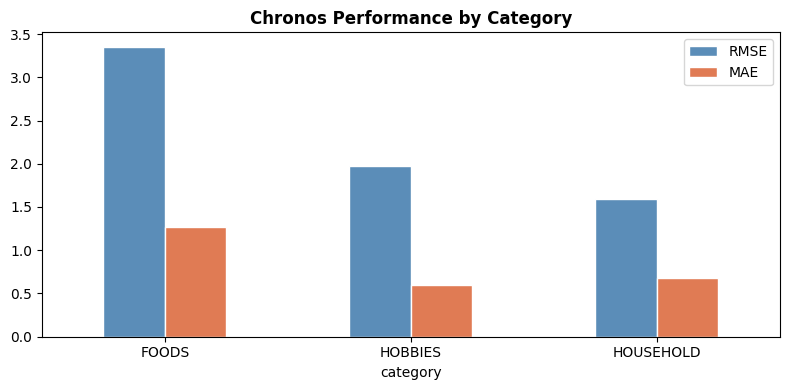

In [ ]:
# RMSE by category from full results
results_df["category"] = results_df["item_id"].str.split("_").str[0]

cat_metrics = results_df.groupby("category").apply(
    lambda x: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(x["actual"], x["pred"])),
        "MAE": mean_absolute_error(x["actual"], x["pred"])
    })
).reset_index()

cat_metrics.plot(x="category", y=["RMSE", "MAE"], kind="bar", figsize=(8,4),
                 color=["#5B8DB8", "#E07B54"], edgecolor="white")
plt.title("Chronos Performance by Category", fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Advance Machine Learning Project - Team 2/chronos_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

- FOODS has the highest error by far (RMSE 3.3) while HOBBIES and HOUSEHOLD are much lower.

- FOODS has way more volatile demand (promotions, SNAP, perishables) so Chronos struggles more there without access to any of those signals. HOBBIES and HOUSEHOLD are more stable/predictable from just history alone

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


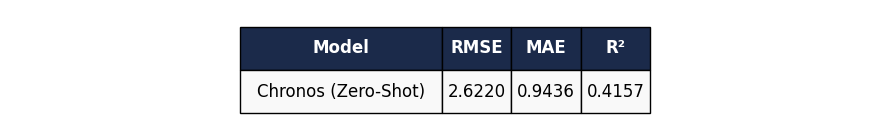

saved!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 1.5))
ax.axis("off")

table = ax.table(
    cellText=[["Chronos (Zero-Shot)", "2.6220", "0.9436", "0.4157"]],
    colLabels=["Model", "RMSE", "MAE", "R²"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.4, 2.5)
table.auto_set_column_width([0, 1, 2, 3])

for j in range(4):
    table[0, j].set_facecolor("#1B2A4A")
    table[0, j].set_text_props(color="white", fontweight="bold")

for j in range(4):
    table[1, j].set_facecolor("#f9f9f9")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Advance Machine Learning Project - Team 2/chronos_metrics_table.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("saved!")

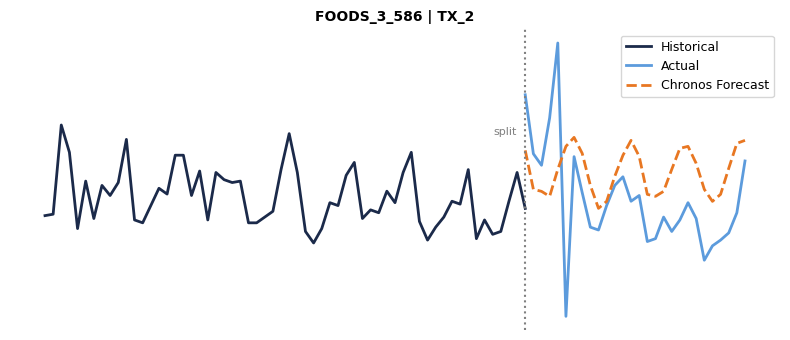

saved!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv("/content/drive/MyDrive/Advance Machine Learning Project - Team 2/chronos_full.csv")

series_stats = results_df.groupby(["item_id", "store_id"]).agg(
    mean_actual=("actual", "mean"),
    n=("actual", "count")
).reset_index()

best = series_stats[series_stats["n"] == 28].nlargest(1, "mean_actual").iloc[0]
item_id, store_id = best["item_id"], best["store_id"]

mask = (results_df["item_id"] == item_id) & (results_df["store_id"] == store_id)
series_results = results_df[mask].reset_index(drop=True)

df_chronos = pd.read_parquet(
    "/content/drive/MyDrive/Advance Machine Learning Project - Team 2/group2_m5_full_feature_dataset_v1.parquet",
    columns=["item_id", "store_id", "date", "sales"]
)
df_chronos["date"] = pd.to_datetime(df_chronos["date"])
split_date = df_chronos["date"].quantile(0.8)

hist = df_chronos[
    (df_chronos["item_id"] == item_id) &
    (df_chronos["store_id"] == store_id)
].set_index("date")["sales"].iloc[-60:]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(len(hist)), hist.values, color="#1B2A4A", linewidth=2, label="Historical")
ax.plot(range(len(hist)-1, len(hist)+len(series_results)-1),
        series_results["actual"].values, color="#4A90D9", linewidth=2, alpha=0.9, label="Actual")
ax.plot(range(len(hist)-1, len(hist)+len(series_results)-1),
        series_results["pred"].values, color="#E87722", linewidth=2, linestyle="--", label="Chronos Forecast")
ax.axvline(x=len(hist)-1, color="gray", linestyle=":", linewidth=1.5)
ax.text(len(hist)-2, hist.values.max()*0.95, "split", fontsize=8, color="gray", ha="right")
ax.set_xticks([])
ax.set_yticks([])
ax.legend(fontsize=9)
ax.set_title(f"{item_id} | {store_id}", fontsize=10, fontweight="bold")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Advance Machine Learning Project - Team 2/chronos_forecast_full.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("saved!")

Chronos gets the general rhythm right, it captures the weekly up-and-down pattern pretty well. but it overestimates slightly as  the orange line sits a bit above the blue line most of the time. It also completely missed that huge spike right at the split, which was probably a promotion or SNAP day.

Chronos captures the underlying demand rhythm from history but  misses sudden spikes caused by external signals it can't see
